#🎼 Reestructuración del ETL para TalkPlayData-2 (NLP-PySpark)
El objetivo es transformar el dataset de diálogos en un formato vectorizado (features) que conserve los metadatos contextuales (speaker_role, emotion, etc.) para un modelo Transformer.

##Paso 0: Instalación y Configuración de PySpark


In [ ]:
# 1. Uninstall existing PySpark and Py4J to clean the environment
!pip uninstall pyspark py4j -y

# 2. Install a stable PySpark 3.x version (e.g., 3.5.1)
!pip install pyspark==3.5.1

# 3. Re-install the necessary Java environment (as previously established)
!apt-get update
!apt-get install openjdk-17-jdk -y

# 4. Set the JAVA_HOME environment variable
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] += os.environ["JAVA_HOME"] + "/bin"

Found existing installation: pyspark 3.5.1
Uninstalling pyspark-3.5.1:
  Successfully uninstalled pyspark-3.5.1
Found existing installation: py4j 0.10.9.7
Uninstalling py4j-0.10.9.7:
  Successfully uninstalled py4j-0.10.9.7
  Using cached pyspark-3.5.1-py2.py3-none-any.whl
  Using cached py4j-0.10.9.7-py2.py3-none-any.whl.metadata (1.5 kB)
Using cached py4j-0.10.9.7-py2.py3-none-any.whl (200 kB)
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu j

In [ ]:
import findspark
findspark.init()

from pyspark.sql import SparkSession
# Importaciones necesarias para su ETL
from pyspark.sql.functions import col, lit, rand, count, mean, explode, when, sum as _sum, avg

# 5. Crear sesión de Spark (Usando el código original)
spark = SparkSession.builder \
    .appName("ETL_TalkPlayData2_Conversacional") \
    .master("local[*]") \
    .getOrCreate()

print("✅ Sesión de Spark 3.5.1 iniciada correctamente. ¡Listo para el ETL!")

✅ Sesión de Spark 3.5.1 iniciada correctamente. ¡Listo para el ETL!


#Paso 1: Carga, Aplanamiento y Enriquecimiento de Datos


In [ ]:
from pyspark.sql.functions import col, explode, when, lit,desc,monotonically_increasing_id

# 1. RUTA DEL ARCHIVO - AJUSTAR ESTO
# Usaremos una ruta de ejemplo de Drive, asegúrate de que esté montado
DRIVE_FILE_PATH = "/content/drive/MyDrive/ia2pdg/talkplay/test-00000-of-00001.parquet"

try:
    # 2. Cargar el archivo Parquet
    df_sessions = spark.read.parquet(DRIVE_FILE_PATH)
    print(f"Total de sesiones cargadas: {df_sessions.count()}")
except Exception as e:
    print(f"❌ Error al cargar el archivo. Verifica la ruta: {DRIVE_FILE_PATH}")
    raise e

# 3. ETL: Aplanamiento y Extracción de Features Contextuales

# Aplanar la lista de 'conversations' para obtener una fila por turno (la unidad del Transformer)
df_turns = df_sessions.select(
    # ID de Sesión (Clave para la división y agrupación)
    col("session_id"),
    # Features del Perfil de Usuario (Features Estáticos)
    col("user_profile.gender").alias("user_gender"),
    col("user_profile.preferred_musical_culture").alias("user_music_culture"),
    # Features del Objetivo de la Conversación (Features Estáticos)
    col("conversation_goal.category").alias("goal_category"),
    col("conversation_goal.listener_goal").alias("goal_description"),
    # Aplanar la lista de turnos (Features Dinámicos)
    explode(col("conversations")).alias("turn")
)

# 4. Proyección Final y Creación de Features de Turno
# Incluiremos las columnas necesarias para el modelo:
# - content_text: El texto o la ID de la canción.
# - speaker_role: El metadato que el Transformer necesita para la codificación.
df_features = df_turns.select(
    # Metadatos de la Sesión
    col("session_id"),
    col("user_gender"),
    col("user_music_culture"),
    col("goal_description"),
    # Features del Turno (Output del Explode)
    col("turn.turn_number").alias("turn_number"),
    col("turn.role").alias("speaker_role"),
    col("turn.content").alias("content_text"),
    # Creación de una columna Target (1 si es una recomendación, 0 si es diálogo)
    when(col("turn.role") == "music", lit(1)).otherwise(lit(0)).alias("is_recommendation_target")
)

# Añadir una ID única global (útil si se necesita re-ordenar después)
df_features = df_features.withColumn("global_turn_id", monotonically_increasing_id())

print("\n✅ DataFrame de Features (Turno a Turno) Listo para División:")
df_features.show(5, truncate=False)
df_features.printSchema()

Total de sesiones cargadas: 1000

✅ DataFrame de Features (Turno a Turno) Listo para División:
+-----------------+-----------+------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------+-----------+------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------------+--------------+
|session_id       |user_gender|user_music_culture      |goal_description                                                                                                                                           |turn_number|speaker_role|content_text                                                                                                                                                       

⚡ Paso 2: División Estratégica de Datos (Train/Validation/Test)
La división por session_id es crucial para mantener la coherencia conversacional.

In [ ]:
from pyspark.sql.functions import rand, count, sum as _sum

# 5. División Estratégica: 80% Train, 10% Validation, 10% Test

# 5.1. Obtener IDs de sesión únicas
session_ids = df_features.select("session_id").distinct().withColumn("rand", rand(seed=42))
total_sessions = session_ids.count()

# Dividir las IDs para cada conjunto (80/10/10)
# Usaremos la lógica de randomSplit con 3 fracciones para simplificar
df_train_ids, df_val_ids, df_test_ids = session_ids.randomSplit([0.80, 0.10, 0.10], seed=42)

# Obtener las listas de IDs
train_ids = [row.session_id for row in df_train_ids.collect()]
validation_ids = [row.session_id for row in df_val_ids.collect()]
test_ids = [row.session_id for row in df_test_ids.collect()]

# 5.2. Aplicar la columna 'dataset_split'
df_split = df_features.withColumn(
    "dataset_split",
    when(col("session_id").isin(train_ids), lit("train"))
    .when(col("session_id").isin(validation_ids), lit("validation"))
    .otherwise(lit("test"))
)

# 5.3. Verificación de la División
total_turns = df_features.count()
print(f"\nTotal de turnos en el dataset completo: {total_turns}")
print("\nVerificación de la División (Porcentaje de Turnos):")
df_split.groupBy("dataset_split").agg(
    count("*").alias("num_turns"),
    (count("*") / total_turns * 100).alias("porcentaje_total")
).orderBy(desc("porcentaje_total")).show()


Total de turnos en el dataset completo: 24000

Verificación de la División (Porcentaje de Turnos):
+-------------+---------+----------------+
|dataset_split|num_turns|porcentaje_total|
+-------------+---------+----------------+
|        train|    20112|            83.8|
|   validation|     2064|             8.6|
|         test|     1824|             7.6|
+-------------+---------+----------------+



#Paso 3: EDA Enfocado en el Conjunto de Entrenamiento (Train)

Ahora que la división está verificada, el código para el EDA y las gráficas se puede ejecutar sin problemas.


Iniciando EDA sobre 20112 turnos de entrenamiento...


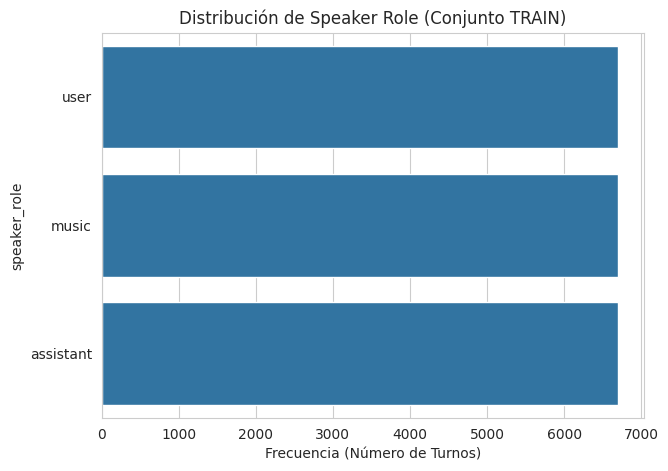


Iniciando EDA sobre 20112 turnos de entrenamiento...


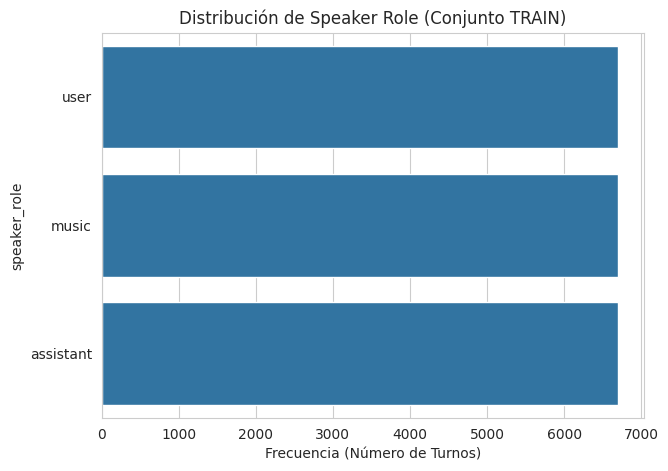

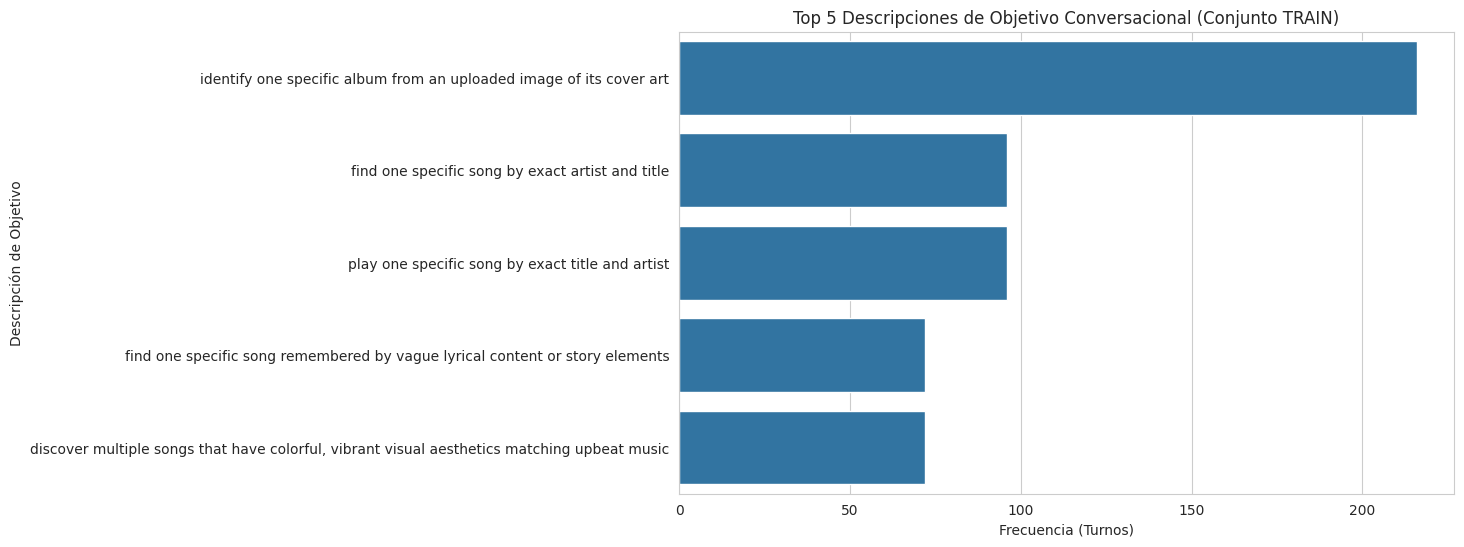

/tmp/ipython-input-4079877231.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rec_rate_by_culture.values, y=rec_rate_by_culture.index, palette="viridis")


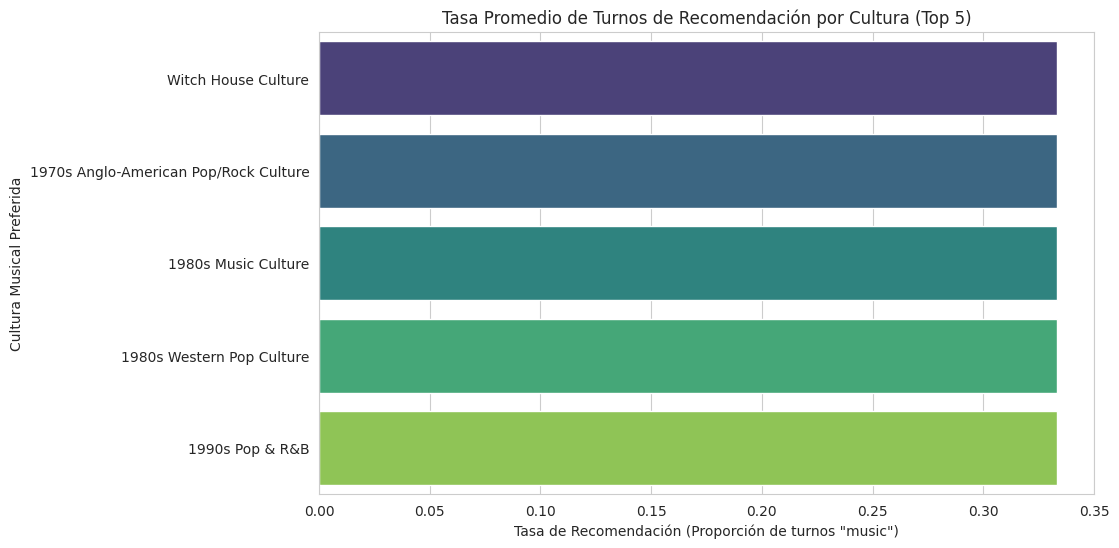


Estadísticas de Longitud de Conversación: Media=8.00


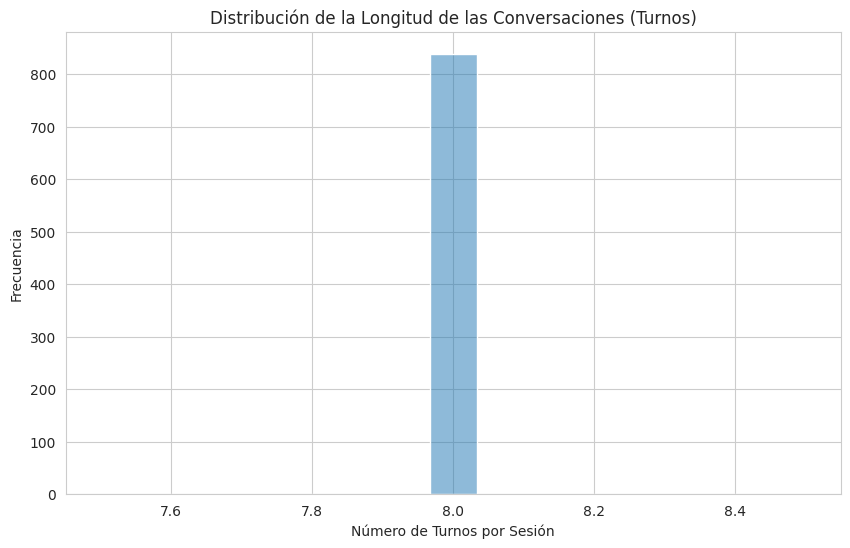

In [ ]:
# Filtramos explícitamente el DataFrame de Entrenamiento antes de convertirlo a Pandas
df_train = df_split.filter(col("dataset_split") == "train")

# (df_train ahora está definido)
df_train_pandas = df_train.toPandas()

print(f"\nIniciando EDA sobre {len(df_train_pandas)} turnos de entrenamiento...")

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 7. FEATURE 1: Distribución del Rol del Hablante (speaker_role)
plt.figure(figsize=(7, 5))
sns.countplot(y='speaker_role', data=df_train_pandas,
              order=df_train_pandas['speaker_role'].value_counts().index)
plt.title('Distribución de Speaker Role (Conjunto TRAIN)')
plt.xlabel('Frecuencia (Número de Turnos)')
plt.show()

# (df_train ya está definido en el paso anterior)
df_train_pandas = df_train.toPandas()

print(f"\nIniciando EDA sobre {len(df_train_pandas)} turnos de entrenamiento...")

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 7. FEATURE 1: Distribución del Rol del Hablante (speaker_role)
plt.figure(figsize=(7, 5))
sns.countplot(y='speaker_role', data=df_train_pandas,
              order=df_train_pandas['speaker_role'].value_counts().index)
plt.title('Distribución de Speaker Role (Conjunto TRAIN)')
plt.xlabel('Frecuencia (Número de Turnos)')
plt.show()

# 8. FEATURE 2: Distribución de la Categoría de Objetivo
plt.figure(figsize=(10, 6))
# **CORRECCIÓN:** Usar 'goal_description' en lugar de 'goal_category'
sns.countplot(y='goal_description', data=df_train_pandas,
              order=df_train_pandas['goal_description'].value_counts().nlargest(5).index)
plt.title('Top 5 Descripciones de Objetivo Conversacional (Conjunto TRAIN)')
plt.xlabel('Frecuencia (Turnos)')
plt.ylabel('Descripción de Objetivo')
plt.show()

# 9. FEATURE 3: Impacto de la Cultura Musical en la Recomendación (Análisis Cruzado)
# Calculamos la tasa de recomendación por cultura musical
rec_rate_by_culture = df_train_pandas.groupby('user_music_culture')['is_recommendation_target'].mean().sort_values(ascending=False).nlargest(5)

plt.figure(figsize=(10, 6))
sns.barplot(x=rec_rate_by_culture.values, y=rec_rate_by_culture.index, palette="viridis")
plt.title('Tasa Promedio de Turnos de Recomendación por Cultura (Top 5)')
plt.xlabel('Tasa de Recomendación (Proporción de turnos "music")')
plt.ylabel('Cultura Musical Preferida')
plt.show()

# 10. FEATURE 4: Longitud Promedio de la Conversación
conversation_length = df_train_pandas.groupby('session_id')['turn_number'].max().reset_index(name='num_turns')
print(f"\nEstadísticas de Longitud de Conversación: Media={conversation_length['num_turns'].mean():.2f}")
plt.figure(figsize=(10, 6))
sns.histplot(conversation_length['num_turns'], bins=15, kde=True)
plt.title('Distribución de la Longitud de las Conversaciones (Turnos)')
plt.xlabel('Número de Turnos por Sesión')
plt.ylabel('Frecuencia')
plt.show()

💾 Paso Final: Guardar los Conjuntos de Datos Divididos

In [ ]:
# Importaciones de PySpark necesarias (si tu sesión no está activa)
# from pyspark.sql.functions import col, lit, when, desc

# 1. Definir la ruta de salida en Google Drive
# ⚠️ ¡AJUSTA ESTA RUTA! Aquí se guardarán tus archivos train, validation y test.
OUTPUT_DIR_SPLITS = "/content/drive/MyDrive/ia2pdg/talkplay/talkplay_datasets_divididos"

print(f"\n## Guardando los conjuntos divididos en: {OUTPUT_DIR_SPLITS}")

# 2. Guardar el conjunto de entrenamiento (Train)
# Usamos .coalesce(1) para forzar un único archivo Parquet por split, facilitando la carga posterior.
df_train = df_split.filter(col("dataset_split") == "train")
df_train.coalesce(1).write.mode("overwrite").parquet(f"{OUTPUT_DIR_SPLITS}/train")
print(f"  - Conjunto Train guardado: {df_train.count()} turnos")

# 3. Guardar el conjunto de validación (Validation)
df_validation = df_split.filter(col("dataset_split") == "validation")
df_validation.coalesce(1).write.mode("overwrite").parquet(f"{OUTPUT_DIR_SPLITS}/validation")
print(f"  - Conjunto Validation guardado: {df_validation.count()} turnos")

# 4. Guardar el conjunto de prueba (Test)
df_test = df_split.filter(col("dataset_split") == "test")
df_test.coalesce(1).write.mode("overwrite").parquet(f"{OUTPUT_DIR_SPLITS}/test")
print(f"  - Conjunto Test guardado: {df_test.count()} turnos")

print("\n✅ Proceso completado. Los conjuntos están listos para la tokenización y el modelado.")

# 5. Finalizar la sesión de Spark
# spark.stop() # Descomenta esta línea si estás al final de tu notebook.


## Guardando los conjuntos divididos en: /content/drive/MyDrive/ia2pdg/talkplay/talkplay_datasets_divididos
  - Conjunto Train guardado: 20112 turnos
  - Conjunto Validation guardado: 2064 turnos
  - Conjunto Test guardado: 1824 turnos

✅ Proceso completado. Los conjuntos están listos para la tokenización y el modelado.
